In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from glob import glob
from scipy.optimize import curve_fit


def get_header_lines(filepath):
    with open(filepath, "r", encoding="latin-1") as f:
        # Skip first line, read second
        f.readline()  
        line2 = f.readline().strip()
    # line2 looks like: "Nb header lines : 76"
    # split by ":" and take the right part
    try:
        n_header = int(line2.split(":")[1])
    except Exception:
        raise ValueError(f"Could not parse header line: {line2}")
    return n_header
cmap = plt.get_cmap('rainbow')

In [5]:
s316 = {'name' : '316'}
s315 = {'name' : '315'}
s234 = {'name' : '234'}
s268 = {'name' : '268'}
s272 = {'name' : '272'}
s274 = {'name' : '274'}
s309 = {'name' : '309'}
s320 = {'name' : '320'}
s322 = {'name' : '322'}
MEA = [s322]


#     for file in mea['files']:
#         print(file)


In [3]:
from matplotlib.ticker import LogLocator, ScalarFormatter, FuncFormatter

# Custom formatter function to specify decimal places
def format_with_precision(x, pos):
    return f"{x:.3f}"  # Change 3 to desired decimal places

# def custom_format(x, pos):
#     """Format ticks with specified values and no trailing zeros."""
#     if x >= 1:
#         return f"{int(x)}" if x.is_integer() else f"{x:.1f}".rstrip('0').rstrip('.')
#     else:
#         return f"{x:.10f}".rstrip('0').rstrip('.')  # For less than 1, use 2 decimal places

def custom_format(x, pos):
    return r"${:,}$".format(int(x)).replace(',', r'\,')


plt.rcParams['text.usetex'] = True
plt.rcParams['axes.formatter.use_locale'] = True

plt.rcParams.update({
    # "font.family": "serif",
    "font.serif": "Tw Cen MT"
})
    

['//ELECTROLYZER/PEM-WE_measurements/2026\\316_III_III Ir50Co50Ox etched RDC907 200 nm\\III_Day1_procedure1_03_SV_C02.mpt', '//ELECTROLYZER/PEM-WE_measurements/2026\\316_III_III Ir50Co50Ox etched RDC907 200 nm\\III_Day2_procedure1_03_SV_C02.mpt']


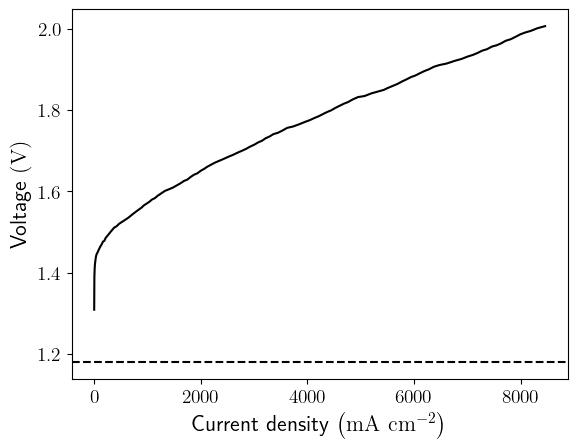

In [232]:
s316['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2026/'+'*'+s316['name']+'*'))
s316['files'] =  glob(os.path.join(s316['folder'][0],'*rocedur*'+'*SV*'+'*.mpt'))
print(s316['files'])
file = s316['files'][0]
with open(file, encoding='latin1') as f:
    df = pd.read_csv(f,delimiter = '\t',skiprows = get_header_lines(file)-1)

# time = df['time/s'].values
t = (df.loc[(df["cycle number"] == 2), 'time/s'].values)
I = (df.loc[(df["cycle number"] == 2), '<I>/mA'].values)
E = (df.loc[(df["cycle number"] == 2), 'Ewe/V'].values)


mask = np.diff(E) > 0 
mask = np.append(mask,False)

plt.plot(I[mask]/4.84,E[mask],c='black')
plt.axhline(1.18,c='black',ls='--')
plt.ylabel(r'Voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
# plt.legend(loc='center right',
#         fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
#         title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/IrCoOx sample.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

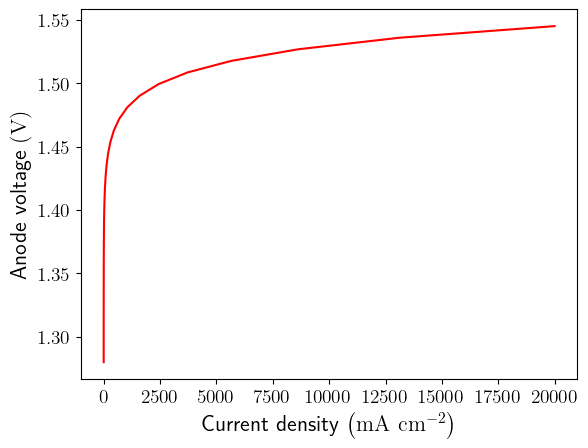

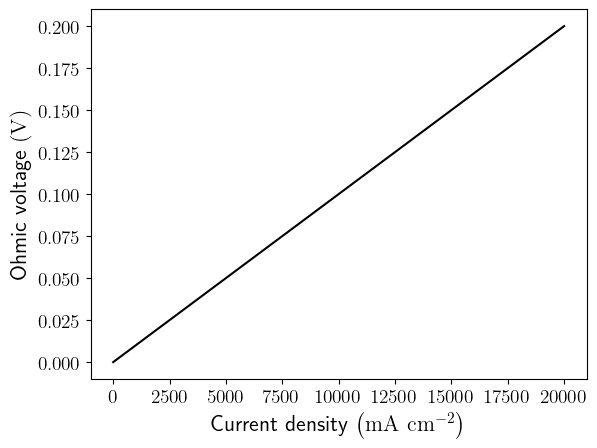

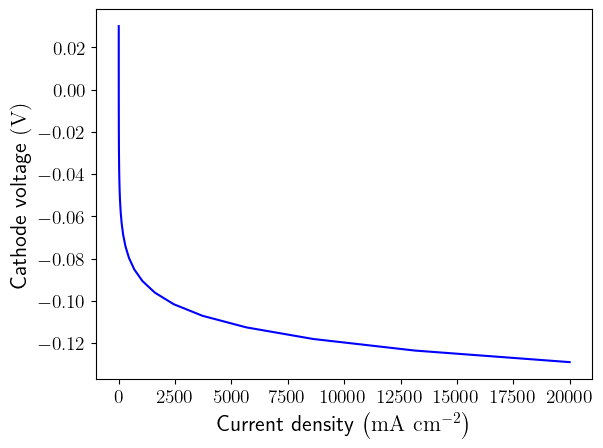

In [237]:
I = np.logspace(-1,np.log10(20000),30)
plt.plot(I,0.05*np.log10(I/0.001)+1.18,c='red')
plt.ylabel(r'Anode voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/IV anode.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()
plt.plot(I,0.00001*I,c='black')
# plt.axhline(1.18,c='black',ls='--')
plt.ylabel(r'Ohmic voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)

plt.xticks(size = 14)
plt.yticks(size = 14)
plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/IV ohmic.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

plt.plot(I,-0.03*np.log10(I),c='blue')
plt.ylabel(r'Cathode voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/IV cathode.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
plt.show()


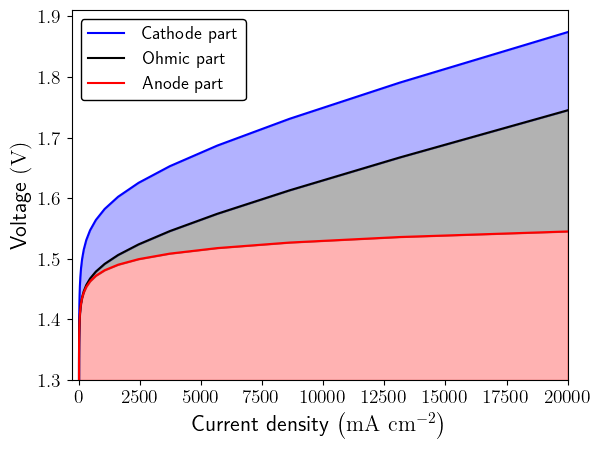

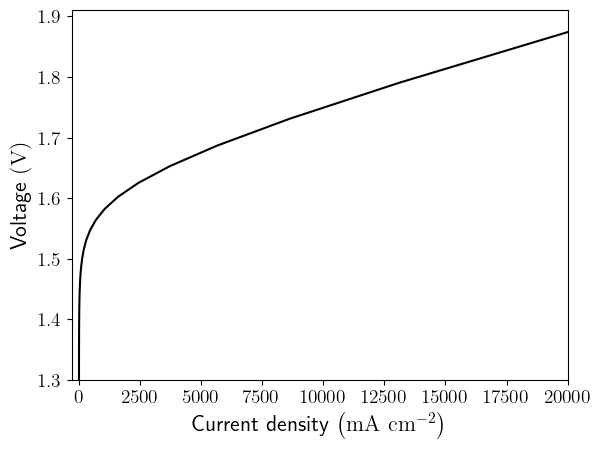

In [260]:
I = np.logspace(-1,np.log10(20000),30)
plt.plot(I,0.05*np.log10(I/0.001)+1.18+0.00001*I+0.03*np.log10(I),c='blue',label='Cathode part')
plt.plot(I,0.05*np.log10(I/0.001)+1.18+0.00001*I,c='black',label='Ohmic part')
plt.plot(I,0.05*np.log10(I/0.001)+1.18,c='red',label='Anode part')
plt.fill_between(I,0.05*np.log10(I/0.001)+1.18,1.3,color = 'red',alpha = 0.3)
plt.fill_between(I,0.05*np.log10(I/0.001)+1.18+0.00001*I,0.05*np.log10(I/0.001)+1.18,color = 'black',alpha = 0.3)
plt.fill_between(I,0.05*np.log10(I/0.001)+1.18+0.00001*I+0.03*np.log10(I),0.05*np.log10(I/0.001)+1.18+0.00001*I,color = 'blue',alpha = 0.3)

plt.ylabel(r'Voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.ylim(1.3,1.91)
plt.xlim(-300,20000)
plt.legend(loc='upper left',
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/IV separated.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
plt.show()
# plt.ylim(1.15,2)


plt.plot(I,0.05*np.log10(I/0.001)+1.18+0.00001*I+0.03*np.log10(I),c='black')
plt.ylabel(r'Voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.ylim(1.3,1.91)
plt.xlim(-300,20000)
plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/IV whole.png',dpi = 1000, format = 'png', bbox_inches = 'tight')
plt.show()




['//ELECTROLYZER/PEM-WE_measurements/2025\\272_I_I Ir 14Ar 1O2, 8 nm Pt + C, Pt wire as reference\\I_procedure1_03_SV.mpt']


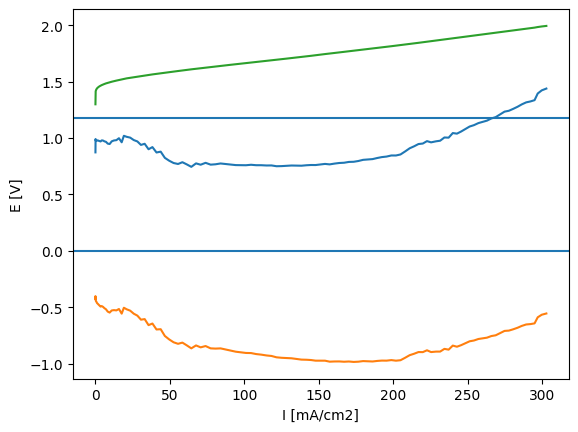

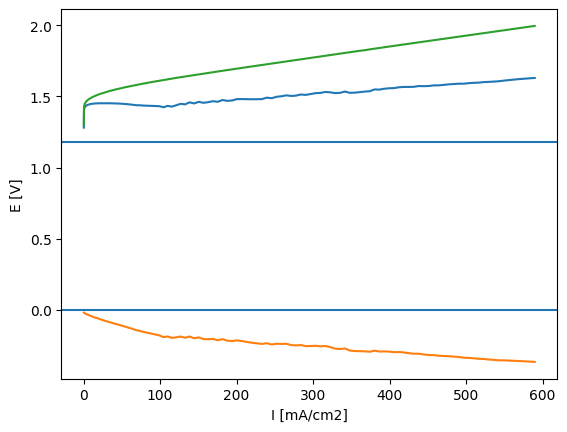

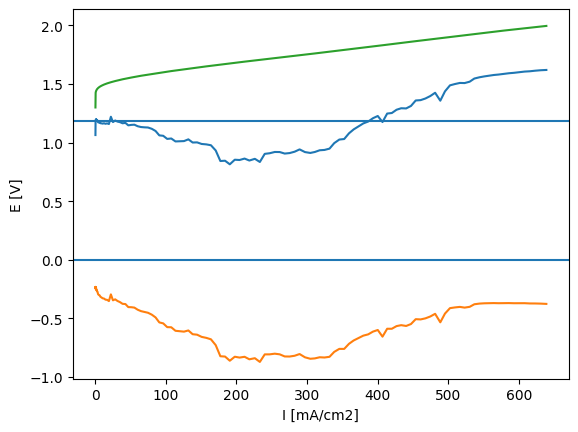

In [30]:
s272['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2025/'+'*'+s272['name']+'*'))
s272['files'] =  glob(os.path.join(s272['folder'][0],'*rocedure1_03*'+'*SV*'+'*.mpt'))
print(s272['files'])
file = s272['files'][0]
with open(file, encoding='latin1') as f:
    df = pd.read_csv(f,delimiter = '\t',skiprows = get_header_lines(file)-1)
for cycle in [9,22,25]:
# time = df['time/s'].values
    t = (df.loc[(df["cycle number"] == cycle), 'time/s'].values)
    I = (df.loc[(df["cycle number"] == cycle), '<I>/mA'].values)
    Ewe = (df.loc[(df["cycle number"] == cycle), 'Ewe/V'].values)
    Ece = (df.loc[(df["cycle number"] == cycle), 'Ece/V'].values)
    Econtrol = (df.loc[(df["cycle number"] == cycle), 'control/V'].values)


    mask = np.diff(Econtrol) > 0 
    mask = np.append(mask,False)

    plt.plot(I[mask]/4.84,Ewe[mask])
    plt.plot(I[mask]/4.84,Ece[mask])
    plt.plot(I[mask]/4.84,Ewe[mask]-Ece[mask])
    plt.axhline(1.18)
    plt.axhline(0)
    plt.xlabel('I [mA/cm2]')
    plt.ylabel('E [V]')
    plt.show()

['//ELECTROLYZER/PEM-WE_measurements/2025\\272_I_I Ir 14Ar 1O2, 8 nm Pt + C, Pt wire as reference\\I_procedure3_03_SV.mpt']


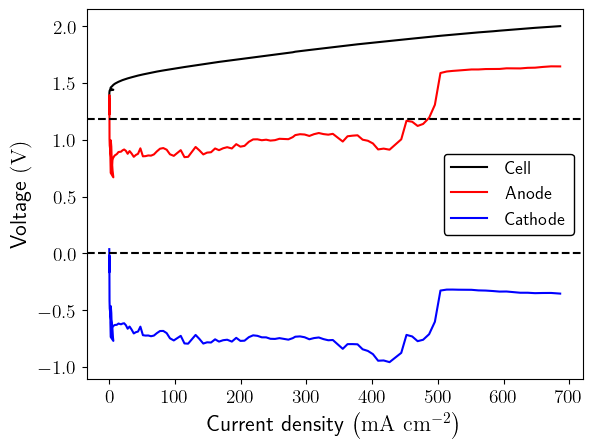

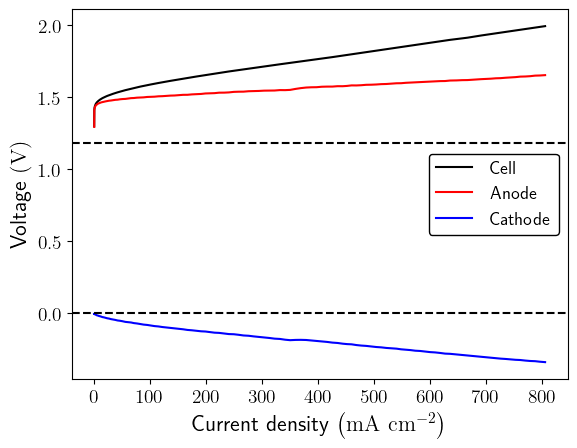

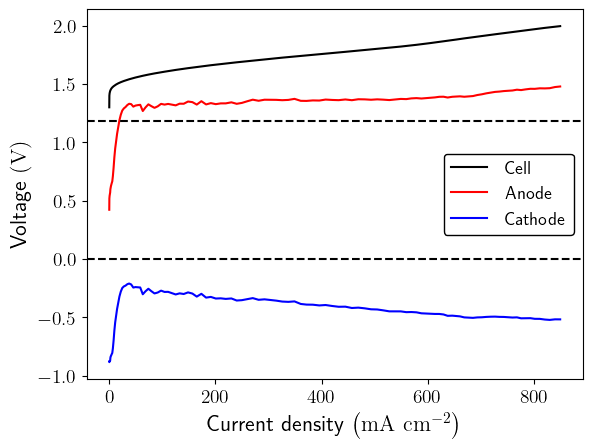

In [230]:
s272['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2025/'+'*'+s272['name']+'*'))
s272['files'] =  glob(os.path.join(s272['folder'][0],'*rocedure3_03*'+'*SV*'+'*.mpt'))
print(s272['files'])
file = s272['files'][0]
with open(file, encoding='latin1') as f:
    df = pd.read_csv(f,delimiter = '\t',skiprows = get_header_lines(file)-1)
for cycle in [1]:
# time = df['time/s'].values
    t = (df.loc[(df["cycle number"] == cycle), 'time/s'].values)
    I = (df.loc[(df["cycle number"] == cycle), '<I>/mA'].values)
    Ewe = (df.loc[(df["cycle number"] == cycle), 'Ewe/V'].values)
    Ece = (df.loc[(df["cycle number"] == cycle), 'Ece/V'].values)
    Econtrol = (df.loc[(df["cycle number"] == cycle), 'control/V'].values)


    mask = np.diff(Econtrol) < 0
    mask = np.append(mask,False)

    plt.plot(I[mask][80:]/4.84,Ewe[mask][80:]-Ece[mask][80:],label = 'Cell',c = 'black')    
    plt.plot(I[mask][80:]/4.84,Ewe[mask][80:],label = 'Anode',c = 'red')
    plt.plot(I[mask][80:]/4.84,Ece[mask][80:],label = 'Cathode',c = 'blue')



    plt.axhline(1.18,ls = '--',c='black')
    plt.axhline(0,ls = '--',c='black')
    plt.ylabel(r'Voltage $\mathrm{ \left( V \right) }$',size=16)
    plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
    plt.legend(loc='center right',
            fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
            title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
    plt.xticks(size = 14)
    plt.yticks(size = 14)
    plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/H2 from II '+str(cycle)+'.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

    plt.show()
    
for cycle in [4,7]:
    
    
# time = df['time/s'].values
    t = (df.loc[(df["cycle number"] == cycle), 'time/s'].values)
    I = (df.loc[(df["cycle number"] == cycle), '<I>/mA'].values)
    Ewe = (df.loc[(df["cycle number"] == cycle), 'Ewe/V'].values)
    Ece = (df.loc[(df["cycle number"] == cycle), 'Ece/V'].values)
    Econtrol = (df.loc[(df["cycle number"] == cycle), 'control/V'].values)


    mask = np.diff(Econtrol) > 0
    mask = np.append(mask,False)
    plt.plot(I[mask]/4.84,Ewe[mask]-Ece[mask],label = 'Cell',c = 'black')
    plt.plot(I[mask]/4.84,Ewe[mask],label = 'Anode',c = 'red')
    plt.plot(I[mask]/4.84,Ece[mask],label = 'Cathode',c = 'blue')

    plt.axhline(1.18,ls = '--',c='black')
    plt.axhline(0,ls = '--',c='black')
    plt.ylabel(r'Voltage $\mathrm{ \left( V \right) }$',size=16)
    plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
    plt.legend(loc='center right',
            fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
            title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
    plt.xticks(size = 14)
    plt.yticks(size = 14)
    plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/H2 from II '+str(cycle)+'.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

    plt.show()

    
    
    
    
    

['//ELECTROLYZER/PEM-WE_measurements/2025\\274_I_I Ir 14Ar 1O2, GDE, Pt wire as reference\\CA_test7_03_OCV.mpt']
1111
101


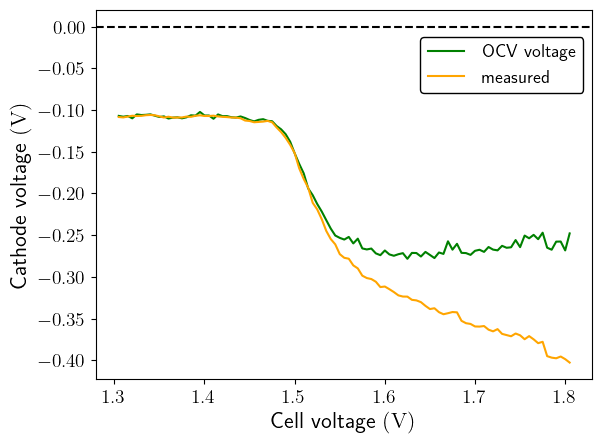

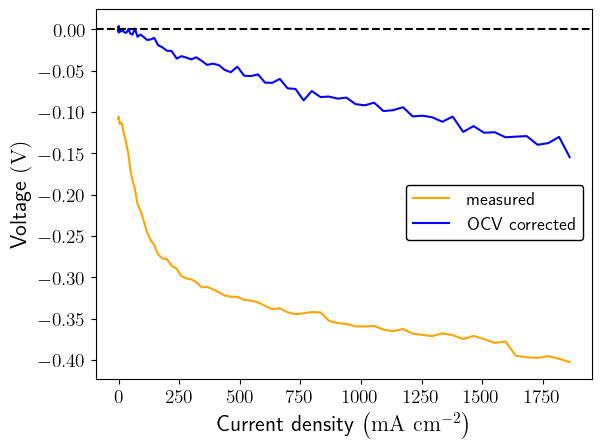

In [14]:


s274['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2025/'+'*'+s274['name']+'*'))
s274['files'] =  glob(os.path.join(s274['folder'][0],'*CA_test7_03_OCV*'+'*.mpt'))
print(s274['files'])
fileOCV = s274['files'][0]
fileCA = glob(os.path.join(s274['folder'][0],'*CA_test7_02_CA*'+'*.mpt'))[0]
with open(fileOCV, encoding='latin1') as f:
    dfOCV = pd.read_csv(f,delimiter = '\t',skiprows = get_header_lines(fileOCV)-1)
with open(fileCA, encoding='latin1') as f:
    dfCA = pd.read_csv(f,delimiter = '\t',skiprows = get_header_lines(fileCA)-1)

# time = df['time/s'].values
tOCV = (dfOCV['time/s'].values)
# tCA = (dfCA['time/s'].values)
# I = (df.loc[(df["cycle number"] == cycle), '<I>/mA'].values)
# Ewe = (df.loc[(df["cycle number"] == cycle), 'Ewe/V'].values)
EceOCV_all = (dfOCV[ '<Ece>/V'].values)
# EceCA = (dfCA[ 'Ece/V'].values)
# Econtrol = (dfCA[ 'control/V'].values)
# Econtrol = (df.loc[(df["cycle number"] == cycle), 'control/V'].values)
EceOCV = []
print(len(EceOCV_all))
unique_vals = np.unique(dfCA["cycle number"].values)

for i in unique_vals:
    EceOCV.append(np.mean(EceOCV_all[11*int(i):11*int(i)+11]))

EceCA = []
ICA = []
Econtrol = []
tCA = []
# print(len(unique_vals))
print(len(EceOCV))
for val in unique_vals:
    ICA.append(np.mean(dfCA.loc[(dfCA["cycle number"] == val) , '<I>/mA'].values))
    tCA.append(np.mean(dfCA.loc[(dfCA["cycle number"] == val) , 'time/s'].values))
    EceCA.append(np.mean(dfCA.loc[(dfCA["cycle number"] == val) , 'Ece/V'].values))
    Econtrol.append(np.mean(dfCA.loc[(dfCA["cycle number"] == val) , 'control/V'].values))


    # mea['Ecell'][PEIS].append(round(np.mean(Ecell[20:]),4))
    # mea['Ea'][PEIS].append(round(np.mean(Ewe[20:]),4))
    # mea['t'][PEIS].append(round(np.mean(time[20:]),4))
    # mea['I'][PEIS].append(round(np.mean(I[:30]),4))
ICA = np.array(ICA)
EceOCV = np.array(EceOCV)
EceCA = np.array(EceCA)
# mask = np.diff(Econtrol) > 0 
# mask = np.append(mask,False)
# print(Econtrol)
plt.plot(Econtrol,EceOCV,c='green',label = 'OCV voltage')
plt.plot(Econtrol,EceCA,c='orange',label = 'measured')
# plt.plot(I[mask]/4.84,Ece[mask])
# plt.plot(I[mask]/4.84,Ewe[mask]-Ece[mask])
# plt.axhline(1.18)
plt.axhline(0,ls = '--',c='black')
plt.ylabel(r'Cathode voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Cell voltage $\mathrm{ \left( V \right) }$',size=16)

plt.legend(loc='upper right',bbox_to_anchor = (1,0.95),
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/OCV correction voltage.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

plt.plot(ICA/4.84,EceCA,c='orange',label = 'measured')
plt.plot(ICA/4.84,EceCA-EceOCV,c='blue',label='OCV corrected')

# plt.plot(I[mask]/4.84,Ece[mask])
# plt.plot(I[mask]/4.84,Ewe[mask]-Ece[mask])
# plt.axhline(1.18)

# plt.axhline(1.18,ls = '--',c='black')
plt.axhline(0,ls = '--',c='black')
plt.ylabel(r'Voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
plt.legend(loc='center right',bbox_to_anchor = (1,0.45),
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/OCV correction SV.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

['//ELECTROLYZER/PEM-WE_measurements/2026\\309_I_I Ir 14Ar1O2, GDE, pressed Pt wire as reference\\I_Day5_Procedure1_05_PEIS.mpt']
[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20.]


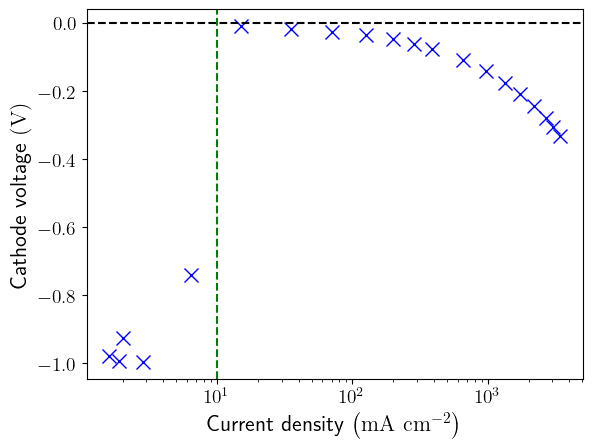

In [268]:
s309['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2026/'+'*'+s309['name']+'*'))
s309['files'] =  glob(os.path.join(s309['folder'][0],'*I_Day5_Procedure1_05_PEIS*'+'*.mpt'))
print(s309['files'])
file = s309['files'][0]
with open(file, encoding='latin1') as f:
    df = pd.read_csv(f,delimiter = '\t',skiprows = get_header_lines(file)-1)
unique_vals = np.unique(df["cycle number"].values)
t = []
print(unique_vals)
I = []
Ewe = []
Ecell = []
for cycle in unique_vals:
# time = df['time/s'].values
    t.append(np.mean(df.loc[(df["cycle number"] == cycle)& (df["freq/Hz"] != 0), 'time/s'].values))
    I.append(np.mean(df.loc[(df["cycle number"] == cycle)& (df["freq/Hz"] != 0), '<I>/mA'].values))
    Ewe.append(np.mean(df.loc[(df["cycle number"] == cycle)& (df["freq/Hz"] != 0), '<Ewe>/V'].values))
    Ecell.append(np.mean(df.loc[(df["cycle number"] == cycle)& (df["freq/Hz"] != 0), '<Ewe-Ece>/V'].values))
    # Econtrol = (df.loc[(df["cycle number"] == cycle), 'control/V'].values)
Ewe = np.array(Ewe)
I = np.array(I)
Ecell = np.array(Ecell)
    # mask = np.diff(Econtrol) > 0 
    # mask = np.append(mask,False)

plt.plot(I/4.84,-Ecell+Ewe,'x',markersize = 10,c='blue')



# plt.axhline(1.18,ls = '--',c='black')
plt.axhline(0,ls = '--',c='black')
plt.axvline(10,ls = '--',c='green')
plt.ylabel(r'Cathode voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
# plt.legend(loc='center right',
#         fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
#         title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.xscale('log')
plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/back to good.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

['//ELECTROLYZER/PEM-WE_measurements/2026/AEM\\320_VI_VI 120 nm Ni on piperion plane, activated after sputtering, RDC 956\\VI_Day1_Procedure9_03_SV_C01.mpt']
-0.08653779920182796


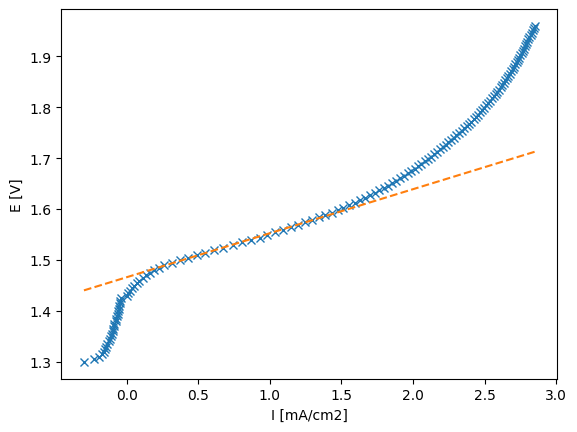

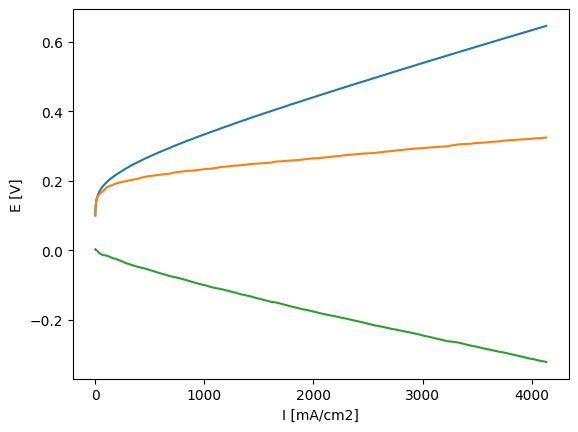

In [153]:
s309['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2026/'+'*'+s309['name']+'*'))
s309['files'] =  glob(os.path.join(s309['folder'][0],'*I_Day5_Procedure2_03_SV*'+'*.mpt'))

file = s309['files'][0]
with open(file, encoding='latin1') as f:
    df = pd.read_csv(f,delimiter = '\t',skiprows = get_header_lines(file)-1)

# time = df['time/s'].values
cycle = 1
t = (df.loc[(df["cycle number"] == cycle), 'time/s'].values)
I = (df.loc[(df["cycle number"] == cycle), '<I>/mA'].values)
E = (df.loc[(df["cycle number"] == cycle), 'control/V'].values)
Ewe = (df.loc[(df["cycle number"] == cycle), 'Ewe/V'].values)
Ece = (df.loc[(df["cycle number"] == cycle), 'Ece/V'].values)


mask = np.diff(E) > 0 
mask = np.append(mask,False)

plt.plot(I[mask]/4.84,E[mask]-1.3)
plt.plot(I[mask]/4.84,Ewe[mask]-1.3)
plt.plot(I[mask]/4.84,Ece[mask])
# plt.axhline(1.18)
plt.xlabel('I [mA/cm2]')
plt.ylabel('E [V]')
plt.show()

//ELECTROLYZER/PEM-WE_measurements/2026\322_I_I Ir 15Ar0,5O2, 8 nm Pt + 30 min C, Pt wire as reference\Day4_Procedure1_03_SV.mpt


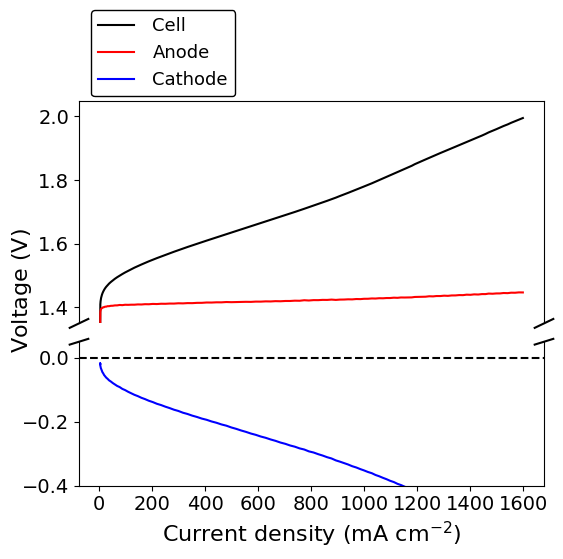

0.011516331345141226


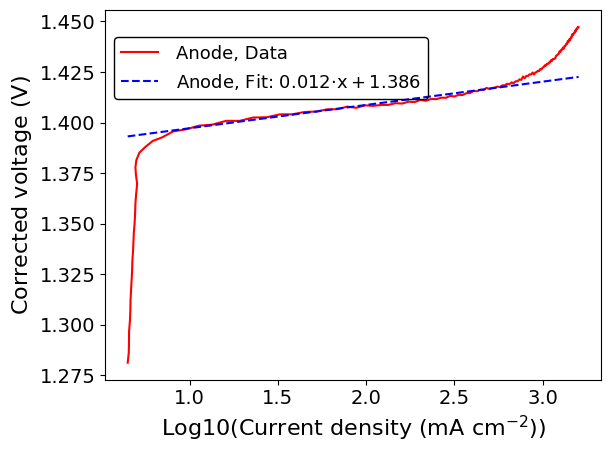

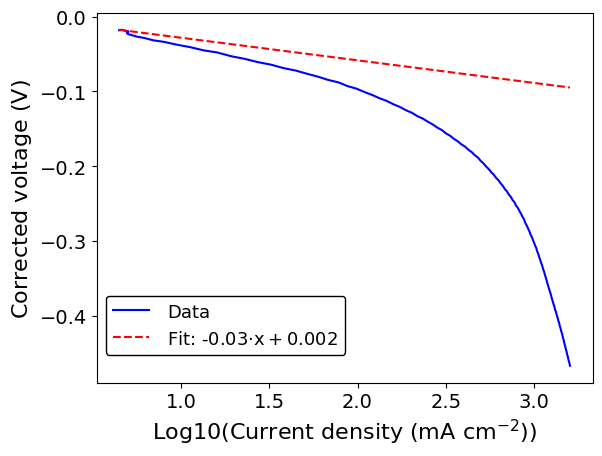

In [14]:
# s309['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2026/'+'*'+s309['name']+'*'))
s322['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2026/'+'*'+s322['name']+'*'))
s322['files'] =  glob(os.path.join(s322['folder'][0],'*Day4_Procedure1_03_SV*'+'*.mpt'))
# s309['files'] =  glob(os.path.join(s309['folder'][0],'*I_Day5_Procedure2_03_SV*'+'*.mpt'))

file = s322['files'][0]
print(file)
with open(file, encoding='latin1') as f:
    df = pd.read_csv(f,delimiter = '\t',skiprows = get_header_lines(file)-1)

# time = df['time/s'].values
cycle = 1
t = (df.loc[(df["cycle number"] == cycle), 'time/s'].values)
I = (df.loc[(df["cycle number"] == cycle), '<I>/mA'].values)
E = (df.loc[(df["cycle number"] == cycle), 'control/V'].values)
Ewe = (df.loc[(df["cycle number"] == cycle), 'Ewe/V'].values)
Ece = (df.loc[(df["cycle number"] == cycle), 'Ece/V'].values)


mask = np.diff(E) > 0 
mask = np.append(mask,False)


fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1, sharex=True, figsize=(6, 5),
    gridspec_kw={"height_ratios": [1.55, 1], "hspace": 0.1}
)

# Plot data
ax_top.plot((I[mask]/4.84),E[mask],c='black',label = 'Cell')
ax_top.plot((I[mask]/4.84),Ewe[mask],c='red',label = 'Anode')

ax_bottom.plot(I[mask]/4.84,Ece[mask],c='blue',label = 'Cathode')

# Set y-limits (this defines the "gap")
ax_top.set_ylim(1.35, 2.05)
ax_bottom.set_ylim(-0.4, 0.05)

# Hide spines
ax_top.spines.bottom.set_visible(False)
ax_bottom.spines.top.set_visible(False)
ax_top.tick_params(labeltop=False)
ax_bottom.xaxis.tick_bottom()

# Diagonal break marks
d = 0.02
kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False)
ax_top.plot((-d, +d), (-d, +d), **kwargs)
ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

kwargs.update(transform=ax_bottom.transAxes)
ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

ax_bottom.set_xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
# ax_bottom.set_ylabel(r'Voltage $\mathrm{ \left( V \right) }$',size=16)


ax_top.tick_params(axis="y", labelsize=14)
ax_bottom.tick_params(axis="both", labelsize=14)
ax_top.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

fig.text(
    0.01,          # x-position (left margin)
    0.5,           # y-position (center of figure)
    r'Voltage $\mathrm{ \left( V \right) }$',
    va="center",
    rotation="vertical",
    fontsize=16
)

# plt.ylabel(r'Voltage $\mathrm{ \left( V \right) }$',size=16)
# plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
fig.legend(loc='lower left',bbox_to_anchor=(0.13,0.87),
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
# ax_bottom.xticks(size = 14)
# ax_bottom.yticks(size = 14)
plt.axhline(0,ls = '--',c = 'black')
# plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/reference example.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

x = np.log10(I[mask]/4.84)
y = Ewe[mask]-0.00*I[mask]/1000
plt.plot(x,y,c='red',label = 'Anode, Data')
k,q = np.polyfit(x[25:45],y[25:45],1)
plt.plot(x,k*x+q,'--',c='blue',label='Anode, Fit: '+str(round(k,3))+'$\mathrm{\cdot x +}$'+str(round(q,3)))
print(k)

# y = E[mask]-0.015*I[mask]/1000
# plt.plot(x,y,c='black',label = 'Cell, Data')
# k,q = np.polyfit(x[:20],y[:20],1)
# plt.plot(x,k*x+q,'--',c='grey',label='Cell, Fit: '+str(round(k,3))+'$\mathrm{\cdot x +}$'+str(round(q,3)))
# print(-k)
# plt.plot(I[mask]/4.84,Ewe[mask]-Ece[mask]
# plt.axhline(1.18)
# plt.axhline(0)
plt.ylabel(r'Corrected voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Log10(Current density $\mathrm{ \left( mA~cm^{-2} \right) }$)',size=16)
plt.legend(loc='upper left',bbox_to_anchor=(0,0.95),
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')

plt.xticks(size = 14)
plt.yticks(size = 14)
# plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEM Tafel anode.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()


# x = (I[mask]/4.84)
# y1 = Ece[mask]
# y2 = Ece[mask]+0.0105*I[mask]/1000
# plt.plot(x,y1,c='blue',label = 'Measured')
# plt.plot(x,y2,'--',c='blue',label = 'Corrected')

# plt.ylabel(r'Cathode voltage $\mathrm{ \left( V \right) }$',size=16)
# plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
# plt.legend(loc='lower left',
#         fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
#         title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')

# plt.xticks(size = 14)
# plt.yticks(size = 14)
# plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEM Tafel cathode correction.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

# plt.show()




# plt.plot(x,k*x+q,'--',c='grey',label='Cell, Fit: '+str(round(k,3))+'$\mathrm{\cdot x +}$'+str(round(q,3)))
# print(-k)
# # plt.plot(I[mask]/4.84,Ewe[mask]-Ece[mask]
# # plt.axhline(1.18)
# # plt.axhline(0)
# plt.ylabel(r'Corrected voltage $\mathrm{ \left( V \right) }$',size=16)
# plt.xlabel(r'Log10(Current density $\mathrm{ \left( mA~cm^{-2} \right) }$)',size=16)
# plt.legend(loc='upper left',bbox_to_anchor=(0,0.95),
#         fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
#         title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')

# plt.xticks(size = 14)
# plt.yticks(size = 14)
# plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEM Tafel anode.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

# plt.show()
x = (I[mask]/4.84)
x = np.log10(x)
y2 = Ece[mask]+0.0105*I[mask]/1000
plt.plot(x,y2,c='blue',label='Data')
k,q = np.polyfit(x[0:15],y2[0:15],1)
plt.plot(x,k*x+q,'--',c='red',label='Fit: '+str(round(k,3))+'$\mathrm{\cdot x +}$'+str(round(q,3)))
# print(-k)
# plt.plot(I[mask]/4.84,Ewe[mask]-Ece[mask]
# plt.axhline(1.18)
# plt.axhline(0)
plt.ylabel(r'Corrected voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Log10(Current density $\mathrm{ \left( mA~cm^{-2} \right) }$)',size=16)
plt.legend(loc='lower left',bbox_to_anchor=(0,0.05),
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')

plt.xticks(size = 14)
plt.yticks(size = 14)
# plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEM Tafel cathode.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()



//ELECTROLYZER/PEM-WE_measurements/2026\315_I_I IrOx from RED 6Ar1O2, 5 min Pt + GDE, Pt wire as reference\I_Day1_Procedure_2_03_SV.mpt


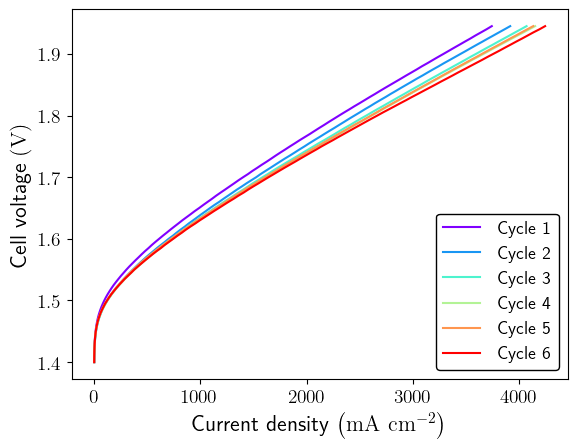

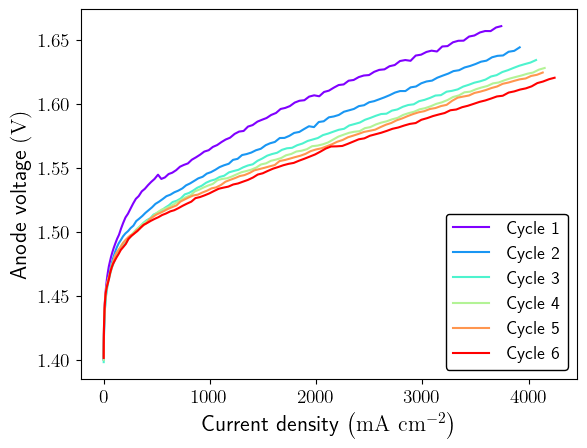

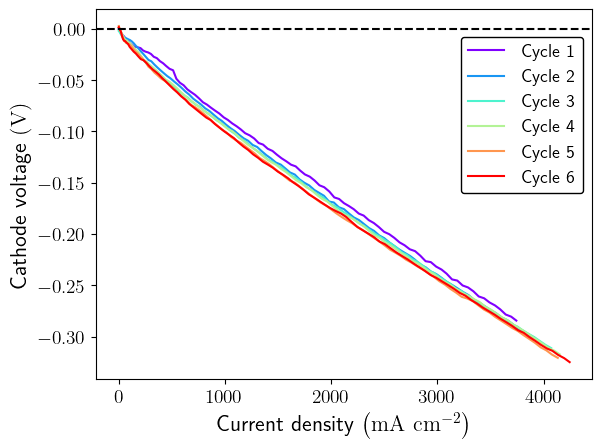

In [191]:
# s309['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2026/'+'*'+s309['name']+'*'))
s315['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2026/'+'*'+s315['name']+'*'))
s315['files'] =  glob(os.path.join(s315['folder'][0],'*I_Day1_Procedure_2_03_SV*'+'*.mpt'))
# s309['files'] =  glob(os.path.join(s309['folder'][0],'*I_Day5_Procedure2_03_SV*'+'*.mpt'))

file = s315['files'][0]
print(file)
with open(file, encoding='latin1') as f:
    df = pd.read_csv(f,delimiter = '\t',skiprows = get_header_lines(file)-1)

# time = df['time/s'].values
cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,6)) 
for cycle in range(2,8):

    t = (df.loc[(df["cycle number"] == cycle), 'time/s'].values)
    I = (df.loc[(df["cycle number"] == cycle), '<I>/mA'].values)
    E = (df.loc[(df["cycle number"] == cycle), 'control/V'].values)
    Ewe = (df.loc[(df["cycle number"] == cycle), 'Ewe/V'].values)
    Ece = (df.loc[(df["cycle number"] == cycle), 'Ece/V'].values)


    mask = np.diff(E) > 0 
    mask = np.append(mask,False)

    plt.plot((I[mask]/4.84),E[mask],c = colors[cycle-2],label = 'Cycle '+str(cycle-1))
plt.ylabel(r'Cell voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
plt.legend(loc='lower right',
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
plt.xticks(size = 14)
plt.yticks(size = 14)
# plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/anode breakin cell.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

for cycle in range(2,8):

    t = (df.loc[(df["cycle number"] == cycle), 'time/s'].values)
    I = (df.loc[(df["cycle number"] == cycle), '<I>/mA'].values)
    E = (df.loc[(df["cycle number"] == cycle), 'control/V'].values)
    Ewe = (df.loc[(df["cycle number"] == cycle), 'Ewe/V'].values)
    Ece = (df.loc[(df["cycle number"] == cycle), 'Ece/V'].values)


    mask = np.diff(E) > 0 
    mask = np.append(mask,False)

    plt.plot((I[mask]/4.84),Ewe[mask],c = colors[cycle-2],label = 'Cycle '+str(cycle-1))
    # plt.plot(I[mask]/4.84,Ece[mask])
    # plt.axhline(1.18)
plt.ylabel(r'Anode voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
plt.legend(loc='lower right',
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
plt.xticks(size = 14)
plt.yticks(size = 14)
# plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/anode breakin anode.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()


for cycle in range(2,8):

    t = (df.loc[(df["cycle number"] == cycle), 'time/s'].values)
    I = (df.loc[(df["cycle number"] == cycle), '<I>/mA'].values)
    E = (df.loc[(df["cycle number"] == cycle), 'control/V'].values)
    Ewe = (df.loc[(df["cycle number"] == cycle), 'Ewe/V'].values)
    Ece = (df.loc[(df["cycle number"] == cycle), 'Ece/V'].values)


    mask = np.diff(E) > 0 
    mask = np.append(mask,False)

    plt.plot((I[mask]/4.84),Ece[mask],c = colors[cycle-2],label = 'Cycle '+str(cycle-1))
    # plt.plot(I[mask]/4.84,Ece[mask])
    # plt.axhline(1.18)
plt.ylabel(r'Cathode voltage $\mathrm{ \left( V \right) }$',size=16)
plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
plt.legend(loc='upper right',bbox_to_anchor=(1,0.95),
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.axhline(0,ls = '--',c = 'black')
# plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/anode breakin cathode.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()








## AEM

['//ELECTROLYZER/PEM-WE_measurements/2026/AEM\\320_VI_VI 120 nm Ni on piperion plane, activated after sputtering, RDC 956\\VI_Day2_Procedure1_03_SV_C01.mpt']


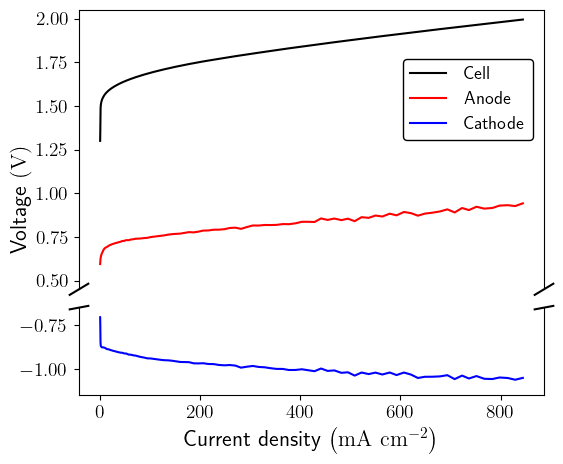

In [26]:
s320['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2026/AEM/'+'*'+s320['name']+'*'))
s320['files'] =  glob(os.path.join(s320['folder'][0],'*Day2_Procedure1*'+'*SV*'+'*.mpt'))
print(s320['files'])
file = s320['files'][0]
with open(file, encoding='latin1') as f:
    df = pd.read_csv(f,delimiter = '\t',skiprows = get_header_lines(file)-1)

    
for cycle in [3]:
# time = df['time/s'].values
    t = (df.loc[(df["cycle number"] == cycle), 'time/s'].values)
    I = (df.loc[(df["cycle number"] == cycle), '<I>/mA'].values)
    Ewe = (df.loc[(df["cycle number"] == cycle), 'Ewe/V'].values)
    Ece = (df.loc[(df["cycle number"] == cycle), 'Ece/V'].values)
    Econtrol = (df.loc[(df["cycle number"] == cycle), 'control/V'].values)


    mask = np.diff(Econtrol) > 0
    mask = np.append(mask,False)
    
    # plt.plot(np.log10(I[mask]/4.84),Ewe[mask]-0.008*I[mask]/1000,'x')

    # y =  Ewe[mask]-0.008*I[mask]/1000
    # y = (Ewe[mask]-Ece[mask])-0.01*I[mask]/1000
    # plt.plot(I[mask]/4.84,Ece[mask],'-')
    # plt.plot(I[mask]/4.84,Ewe[mask],'-')

    fig, (ax_top, ax_bottom) = plt.subplots(
        2, 1, sharex=True, figsize=(6, 5),
        gridspec_kw={"height_ratios": [3.2, 1], "hspace": 0.1}
    )

    # Plot data
    ax_top.plot((I[mask]/4.84),Econtrol[mask],c='black',label = 'Cell')
    ax_top.plot((I[mask]/4.84),Ewe[mask],c='red',label = 'Anode')

    ax_bottom.plot(I[mask]/4.84,Ece[mask],c='blue',label = 'Cathode')

    # Set y-limits (this defines the "gap")
    ax_top.set_ylim(0.45, 2.05)
    ax_bottom.set_ylim(-1.15, -0.65)

    # Hide spines
    ax_top.spines.bottom.set_visible(False)
    ax_bottom.spines.top.set_visible(False)
    ax_top.tick_params(labeltop=False)
    ax_bottom.xaxis.tick_bottom()

    # Diagonal break marks
    d = 0.02
    kwargs = dict(transform=ax_top.transAxes, color="k", clip_on=False)
    ax_top.plot((-d, +d), (-d, +d), **kwargs)
    ax_top.plot((1 - d, 1 + d), (-d, +d), **kwargs)

    kwargs.update(transform=ax_bottom.transAxes)
    ax_bottom.plot((-d, +d), (1 - d, 1 + d), **kwargs)
    ax_bottom.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

    ax_bottom.set_xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
    # ax_bottom.set_ylabel(r'Voltage $\mathrm{ \left( V \right) }$',size=16)


    ax_top.tick_params(axis="y", labelsize=14)
    ax_bottom.tick_params(axis="both", labelsize=14)
    ax_top.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

    fig.text(
        0.01,          # x-position (left margin)
        0.5,           # y-position (center of figure)
        r'Voltage $\mathrm{ \left( V \right) }$',
        va="center",
        rotation="vertical",
        fontsize=16
    )

    # plt.ylabel(r'Voltage $\mathrm{ \left( V \right) }$',size=16)
    # plt.xlabel(r'Current density $\mathrm{ \left( mA~cm^{-2} \right) }$',size=16)
    fig.legend(loc='upper left',bbox_to_anchor=(0.65,0.8),
            fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
            title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
    # ax_bottom.xticks(size = 14)
    # ax_bottom.yticks(size = 14)
    # plt.axhline(0,ls = '--',c = 'black')
    plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/AEM reference example.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

    plt.show()


['//ELECTROLYZER/PEM-WE_measurements/2026/AEM\\320_VI_VI 120 nm Ni on piperion plane, activated after sputtering, RDC 956\\VI_Day2_Procedure1_03_SV_C01.mpt']
-0.06475420687923342


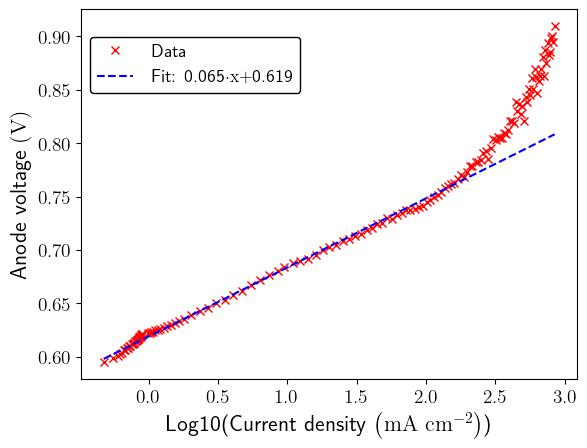

0.018802974928982762


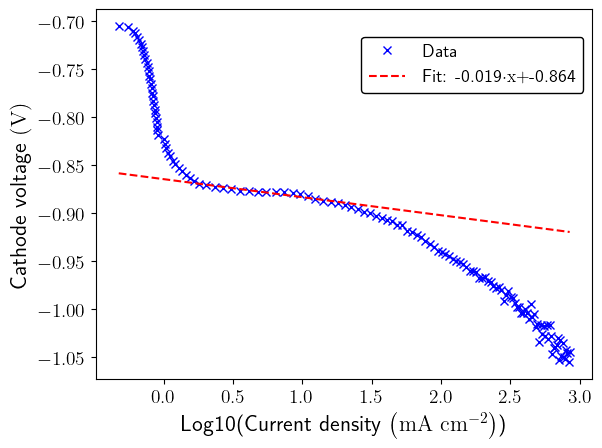

In [37]:
s320['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2026/AEM/'+'*'+s320['name']+'*'))
s320['files'] =  glob(os.path.join(s320['folder'][0],'*Day2_Procedure1*'+'*SV*'+'*.mpt'))
print(s320['files'])
file = s320['files'][0]
with open(file, encoding='latin1') as f:
    df = pd.read_csv(f,delimiter = '\t',skiprows = get_header_lines(file)-1)

    
for cycle in [3]:
# time = df['time/s'].values
    t = (df.loc[(df["cycle number"] == cycle), 'time/s'].values)
    I = (df.loc[(df["cycle number"] == cycle), '<I>/mA'].values)
    Ewe = (df.loc[(df["cycle number"] == cycle), 'Ewe/V'].values)
    Ece = (df.loc[(df["cycle number"] == cycle), 'Ece/V'].values)
    Econtrol = (df.loc[(df["cycle number"] == cycle), 'control/V'].values)


    mask = np.diff(Econtrol) > 0
    mask = np.append(mask,False)
    
    # plt.plot(np.log10(I[mask]/4.84),Ewe[mask]-0.008*I[mask]/1000,'x')
    x = np.log10(I[mask]/4.84)
    # y = Ece[mask]+0.002*I[mask]/1000
    y =  Ewe[mask]-0.008*I[mask]/1000
    # y = (Ewe[mask]-Ece[mask])-0.01*I[mask]/1000
    plt.plot(x,y,'x',c='red',label='Data')
    k,q = np.polyfit(x[40:60],y[40:60],1)
    plt.plot(x,k*x+q,'--',c='blue',label='Fit: '+str(round(k,3))+'$\mathrm{\cdot x +}$'+str(round(q,3)))
    print(-k)
    # plt.plot(I[mask]/4.84,Ewe[mask]-Ece[mask]
    # plt.axhline(1.18)
    # plt.axhline(0)
    plt.ylabel(r'Anode voltage $\mathrm{ \left( V \right) }$',size=16)
    plt.xlabel(r'Log10(Current density $\mathrm{ \left( mA~cm^{-2} \right) }$)',size=16)
    plt.legend(loc='upper left',bbox_to_anchor=(0,0.95),
            fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
            title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
    plt.xticks(size = 14)
    plt.yticks(size = 14)

    plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/AEM Tafel anode.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

    plt.show()
    
    x = np.log10(I[mask]/4.84)
    y = Ece[mask]+0.002*I[mask]/1000
    # y =  Ewe[mask]-0.008*I[mask]/1000
    # y = (Ewe[mask]-Ece[mask])-0.01*I[mask]/1000
    plt.plot(x,y,'x',c='blue',label='Data')
    k,q = np.polyfit(x[40:60],y[40:60],1)
    plt.plot(x,k*x+q,'--',c='red',label='Fit: '+str(round(k,3))+'$\mathrm{\cdot x +}$'+str(round(q,3)))
    print(-k)
    # plt.plot(I[mask]/4.84,Ewe[mask]-Ece[mask]
    # plt.axhline(1.18)
    # plt.axhline(0)
    plt.ylabel(r'Cathode voltage $\mathrm{ \left( V \right) }$',size=16)
    plt.xlabel(r'Log10(Current density $\mathrm{ \left( mA~cm^{-2} \right) }$)',size=16)
    plt.legend(loc='upper right',bbox_to_anchor=(1,0.95),
            fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
            title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
    plt.xticks(size = 14)
    plt.yticks(size = 14)

    plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/AEM Tafel cathode.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

    plt.show()


['//ELECTROLYZER/PEM-WE_measurements/2026/AEM\\320_VI_VI 120 nm Ni on piperion plane, activated after sputtering, RDC 956\\VI_Day2_Procedure1_03_SV_C01.mpt']
-0.06475420687923342


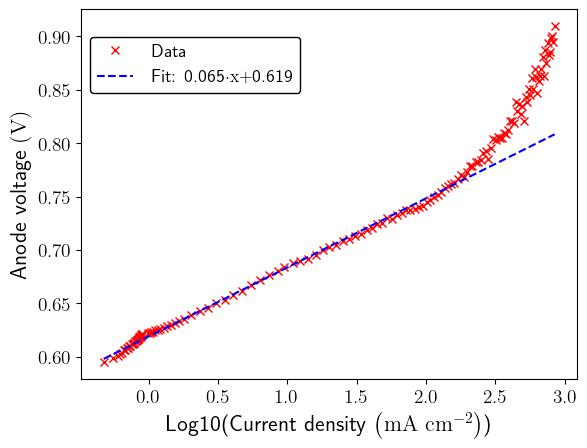

0.018802974928982762


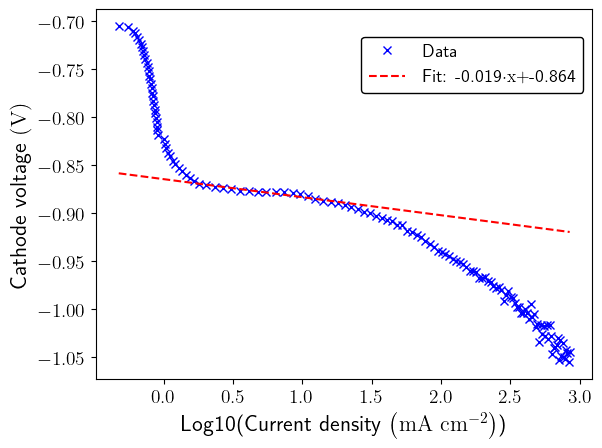

In [23]:
s320['folder']= glob(os.path.join('//ELECTROLYZER/PEM-WE_measurements/2026/AEM/'+'*'+s320['name']+'*'))
s320['files'] =  glob(os.path.join(s320['folder'][0],'*Day2_Procedure1*'+'*SV*'+'*.mpt'))
print(s320['files'])
file = s320['files'][0]
with open(file, encoding='latin1') as f:
    df = pd.read_csv(f,delimiter = '\t',skiprows = get_header_lines(file)-1)

    
for cycle in [3]:
# time = df['time/s'].values
    t = (df.loc[(df["cycle number"] == cycle), 'time/s'].values)
    I = (df.loc[(df["cycle number"] == cycle), '<I>/mA'].values)
    Ewe = (df.loc[(df["cycle number"] == cycle), 'Ewe/V'].values)
    Ece = (df.loc[(df["cycle number"] == cycle), 'Ece/V'].values)
    Econtrol = (df.loc[(df["cycle number"] == cycle), 'control/V'].values)


    mask = np.diff(Econtrol) > 0
    mask = np.append(mask,False)
    
    # plt.plot(np.log10(I[mask]/4.84),Ewe[mask]-0.008*I[mask]/1000,'x')
    x = np.log10(I[mask]/4.84)
    # y = Ece[mask]+0.002*I[mask]/1000
    y =  Ewe[mask]-0.008*I[mask]/1000
    # y = (Ewe[mask]-Ece[mask])-0.01*I[mask]/1000
    plt.plot(x,y,'x',c='red',label='Data')
    k,q = np.polyfit(x[40:60],y[40:60],1)
    plt.plot(x,k*x+q,'--',c='blue',label='Fit: '+str(round(k,3))+'$\mathrm{\cdot x +}$'+str(round(q,3)))
    print(-k)
    # plt.plot(I[mask]/4.84,Ewe[mask]-Ece[mask]
    # plt.axhline(1.18)
    # plt.axhline(0)
    plt.ylabel(r'Anode voltage $\mathrm{ \left( V \right) }$',size=16)
    plt.xlabel(r'Log10(Current density $\mathrm{ \left( mA~cm^{-2} \right) }$)',size=16)
    plt.legend(loc='upper left',bbox_to_anchor=(0,0.95),
            fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
            title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
    plt.xticks(size = 14)
    plt.yticks(size = 14)

    # plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/AEM Tafel anode.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

    plt.show()
    
    x = np.log10(I[mask]/4.84)
    y = Ece[mask]+0.002*I[mask]/1000
    # y =  Ewe[mask]-0.008*I[mask]/1000
    # y = (Ewe[mask]-Ece[mask])-0.01*I[mask]/1000
    plt.plot(x,y,'x',c='blue',label='Data')
    k,q = np.polyfit(x[40:60],y[40:60],1)
    plt.plot(x,k*x+q,'--',c='red',label='Fit: '+str(round(k,3))+'$\mathrm{\cdot x +}$'+str(round(q,3)))
    print(-k)
    # plt.plot(I[mask]/4.84,Ewe[mask]-Ece[mask]
    # plt.axhline(1.18)
    # plt.axhline(0)
    plt.ylabel(r'Cathode voltage $\mathrm{ \left( V \right) }$',size=16)
    plt.xlabel(r'Log10(Current density $\mathrm{ \left( mA~cm^{-2} \right) }$)',size=16)
    plt.legend(loc='upper right',bbox_to_anchor=(1,0.95),
            fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
            title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('none')
    plt.xticks(size = 14)
    plt.yticks(size = 14)

    # plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/AEM Tafel cathode.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

    plt.show()


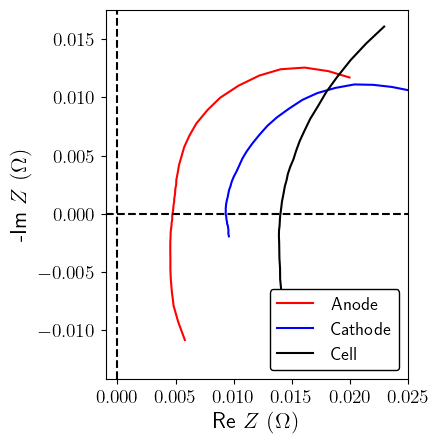

In [8]:
data = np.loadtxt('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS_MV_data.txt',skiprows = 2)
plt.plot(data[:,0][25:],data[:,1][25:],c='red',label = 'Anode')
plt.plot(data[:,2][30:],data[:,3][30:],c='blue',label = 'Cathode')
plt.plot(data[:,4][35:],data[:,5][35:],c='black',label = 'Cell')
plt.gca().set_aspect('equal')
plt.ylabel(r'-Im $Z$ $\mathrm{ \left( \Omega \right) }$',size=16)
plt.xlabel(r'Re $Z$ $\mathrm{ \left( \Omega \right) }$',size=16)
plt.legend(loc='lower right',
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('white')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.xlim(-0.001,0.025)
plt.axhline(0,ls='--',c='black')
plt.axvline(0,ls='--',c='black')
plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/ohmic all.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

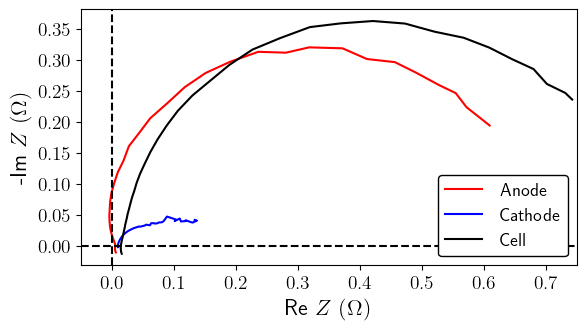

In [35]:
data = np.loadtxt('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS_LV_data.txt',skiprows = 2)
plt.plot(data[:,0],data[:,1],c='red',label = 'Anode')
plt.plot(data[:,2],data[:,3],c='blue',label = 'Cathode')
plt.plot(data[:,4],data[:,5],c='black',label = 'Cell')
plt.gca().set_aspect('equal')
plt.ylabel(r'-Im $Z$ $\mathrm{ \left( \Omega \right) }$',size=16)
plt.xlabel(r'Re $Z$ $\mathrm{ \left( \Omega \right) }$',size=16)
plt.legend(loc='lower right',
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('white')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.xlim(-0.05,0.75)
plt.axhline(0,ls='--',c='black')
plt.axvline(0,ls='--',c='black')
plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS LV.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

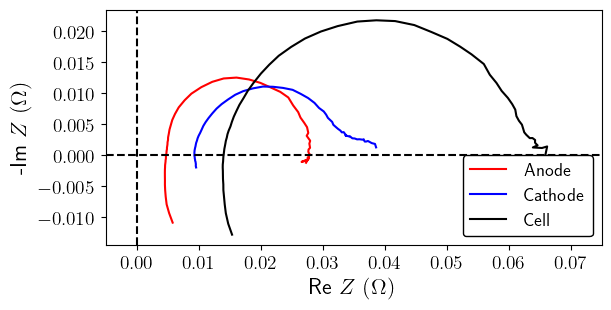

In [36]:
data = np.loadtxt('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS_MV_data.txt',skiprows = 2)
plt.plot(data[:,0],data[:,1],c='red',label = 'Anode')
plt.plot(data[:,2],data[:,3],c='blue',label = 'Cathode')
plt.plot(data[:,4],data[:,5],c='black',label = 'Cell')
plt.gca().set_aspect('equal')
plt.ylabel(r'-Im $Z$ $\mathrm{ \left( \Omega \right) }$',size=16)
plt.xlabel(r'Re $Z$ $\mathrm{ \left( \Omega \right) }$',size=16)
plt.legend(loc='lower right',
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('white')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.xlim(-0.005,0.075)
plt.axhline(0,ls='--',c='black')
plt.axvline(0,ls='--',c='black')
            

plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS MV.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

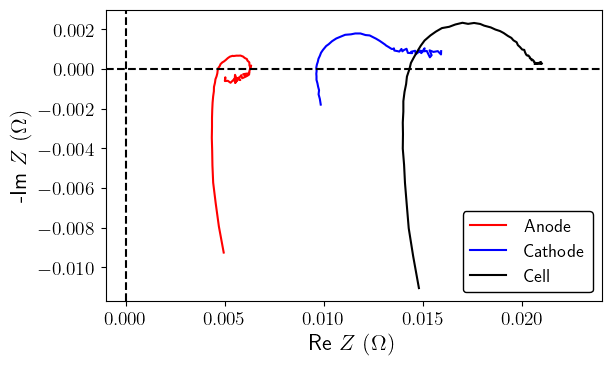

In [37]:
data = np.loadtxt('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS_HV_data.txt',skiprows = 2)
plt.plot(data[:,0],data[:,1],c='red',label = 'Anode')
plt.plot(data[:,2],data[:,3],c='blue',label = 'Cathode')
plt.plot(data[:,4],data[:,5],c='black',label = 'Cell')
plt.gca().set_aspect('equal')
plt.ylabel(r'-Im $Z$ $\mathrm{ \left( \Omega \right) }$',size=16)
plt.xlabel(r'Re $Z$ $\mathrm{ \left( \Omega \right) }$',size=16)
plt.legend(loc='lower right',
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('white')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.xlim(-0.001,0.024)
plt.axhline(0,ls='--',c='black')
plt.axvline(0,ls='--',c='black')
            

plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS HV.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

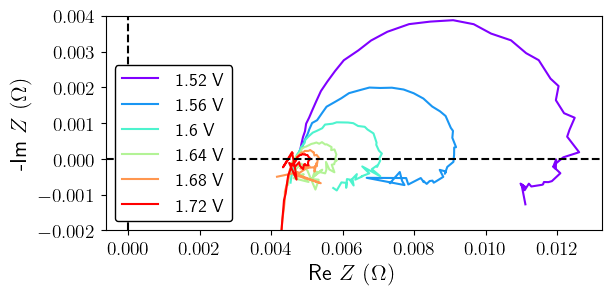

In [82]:
file = r'C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS_anode_ind_loops.txt'
with open(file, encoding='latin1') as f:
    data = pd.read_csv(f,delimiter = '\t',skiprows = 2).values
    
cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,6)) 
for i in range(0,6):
    plt.plot(data[:,2*i][:50],data[:,2*i+1][:50],c=colors[i],label = str(round(1.52+i*0.04,3))+' V')

# data = np.loadtxt('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS_anode_ind_loops.txt',skiprows = 2,usecols = (4))
# plt.plot(data[:,0],data[:,1],c='red',label = 'Anode')
# plt.plot(data[:,2],data[:,3],c='red',label = 'Anode')
# data = np.loadtxt('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS_anode_ind_loops.txt',skiprows = 2,usecols = (8,9,10,11))
# plt.plot(data[:,0],data[:,1],c='red',label = 'Anode')
# plt.plot(data[:,2],data[:,3],c='red',label = 'Anode')
# plt.plot(data[:,2],data[:,3],c='blue',label = 'Cathode')
# plt.plot(data[:,4],data[:,5],c='black',label = 'Cell')
plt.gca().set_aspect('equal')
plt.ylabel(r'-Im $Z$ $\mathrm{ \left( \Omega \right) }$',size=16)
plt.xlabel(r'Re $Z$ $\mathrm{ \left( \Omega \right) }$',size=16)
plt.legend(loc='lower left',
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('white')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.ylim(-0.002,0.004)
plt.axhline(0,ls='--',c='black')
plt.axvline(0,ls='--',c='black')
            

plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS ind loopes.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()

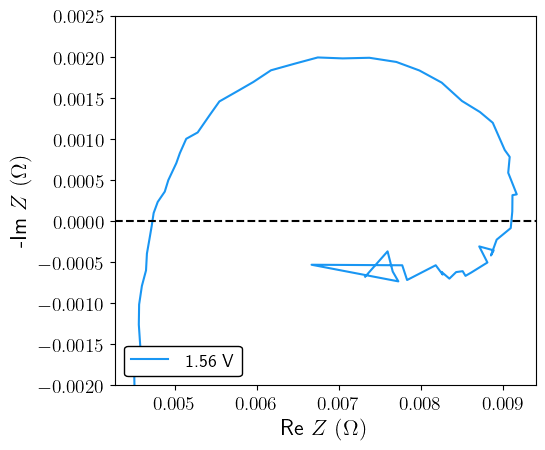

In [10]:
file = r'C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS_anode_ind_loops.txt'
with open(file, encoding='latin1') as f:
    data = pd.read_csv(f,delimiter = '\t',skiprows = 2).values
    
cmap = plt.get_cmap('rainbow')
colors = cmap(np.linspace(0,1,6)) 
for i in range(1,2):
    plt.plot(data[:,2*i][:60],data[:,2*i+1][:60],c=colors[i],label = str(round(1.52+i*0.04,3))+' V')

# data = np.loadtxt('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS_anode_ind_loops.txt',skiprows = 2,usecols = (4))
# plt.plot(data[:,0],data[:,1],c='red',label = 'Anode')
# plt.plot(data[:,2],data[:,3],c='red',label = 'Anode')
# data = np.loadtxt('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS_anode_ind_loops.txt',skiprows = 2,usecols = (8,9,10,11))
# plt.plot(data[:,0],data[:,1],c='red',label = 'Anode')
# plt.plot(data[:,2],data[:,3],c='red',label = 'Anode')
# plt.plot(data[:,2],data[:,3],c='blue',label = 'Cathode')
# plt.plot(data[:,4],data[:,5],c='black',label = 'Cell')
plt.gca().set_aspect('equal')
plt.ylabel(r'-Im $Z$ $\mathrm{ \left( \Omega \right) }$',size=16)
plt.xlabel(r'Re $Z$ $\mathrm{ \left( \Omega \right) }$',size=16)
plt.legend(loc='lower left',
        fontsize=13, ncol=1,handletextpad = 1,columnspacing = 0.5,borderpad = 0.4,
        title_fontsize = 13,alignment = 'left',edgecolor='0',framealpha=1).get_frame().set_facecolor('white')
plt.xticks(size = 14)
plt.yticks(size = 14)
plt.ylim(-0.002,0.0025)
plt.axhline(0,ls='--',c='black')
# plt.axvline(0,ls='--',c='black')
            

plt.savefig('C:/Users/Herman/Desktop/MFF/PhD/Škola/winter seminar 2026/PEIS ind loop1.png',dpi = 1000, format = 'png', bbox_inches = 'tight')

plt.show()